Objetivo: caracterizar las clientas y las prendas de manera que sea posible predecir si la reacción a la prenda será positiva o negativa.

In [9]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [10]:
ruta = "Datos/Originales/Datos look&like"

In [11]:
df_look_like = pd.read_csv(os.path.join(ruta, "look_and_like_data_2.csv"), sep=";")
df_customers = pd.read_csv(os.path.join(ruta, "customers_data_2.csv"), sep=";")
df_items = pd.read_csv(os.path.join(ruta, "items_data.csv"), sep=",")

print("Look & Like shape:", df_look_like.shape)
print("Customers shape:", df_customers.shape)
print("Items shape:", df_items.shape)

Look & Like shape: (349262, 5)
Customers shape: (387, 26)
Items shape: (27074, 46)


Limpieza de items

In [12]:
df_items.head()

,product_variant_id,season,family,brand,model,color,size,adventurous,back_neckline,basic,...,sleeve_long,sleeve_long_cm,sole_length,style,thicknees,toecap,type_of_length,waist_contour,weather,current_price_eur
0,0002d203-bf19-42fd-8c82-892780d2d39b,13,blusa_camisa,PIECES,S4789,blue_dark,S,"three,two",NaN,NaN,...,short_sleeve,22.0,NaN,"boho,classic",NaN,NaN,NaN,54.0,"warm,warm_season",3499
1,001315a9-6c15-4907-88d5-db6d04e8863e,11,vestido,FRANSA,D2894,black,L,two,NaN,False,...,long_sleeve,63.0,NaN,"classic,minimal",NaN,NaN,midi,60.0,cold_season,5999
2,0020adc1-b9cf-48d0-b047-0adc55b4caea,12,vestido,THE BOHCK,D3436,black,XXXL,three,NaN,NaN,...,short_sleeve,20.0,NaN,"boho,street",NaN,NaN,NaN,46.0,"warm,warm_season",5490
3,0022833c-4a75-4bcb-81d3-29b921094e53,15,pantalon,LA FÉE MARABOUTEÉ,P3874,green,L,three,NaN,NaN,...,NaN,NaN,NaN,"boho,street",NaN,NaN,long,36.0,"warm,warm_season",13600
4,0022c48d-d65c-4a98-a6ff-e229e7b9e025,11,blusa_camisa,VERO MODA,S3580,white,M,"three,two",NaN,False,...,long_sleeve,60.0,NaN,"boho,street",NaN,NaN,NaN,49.0,"cold_season,warm_season",3999


In [13]:
df_items.shape

(27074, 46)

Conservamos únicamente las familias de arriba

In [14]:
df_items['family'].unique()

array(['blusa_camisa', 'vestido', 'pantalon', 'jersey', 'top', 'sudadera',
       'camiseta', 'falda', 'short', 'denim_jeans', 'chaqueta',
       'cardigan', 'bufanda', 'jumpsuit', 'botines', 'bolso', 'parka',
       'sandalias', 'fular', 'sneakers', 'abrigo', 'zapatos', 'botas',
       'trench', 'camiseta_deportiva'], dtype=object)

In [15]:
subconjunto = ['blusa_camisa', 'vestido', 'jersey', 'top', 'sudadera', 'camiseta', 'chaqueta', 'cardigan', 'jumpsuit', 'camiseta_deportiva']
df_items = df_items[df_items['family'].isin(subconjunto)]

Limpienza de variables en función de mmissing values y redundancia

In [16]:
missing_percentage = df_items.isnull().mean() * 100
missing_report = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print(missing_report)

heel_length           100.000000
toecap                100.000000
size_feature          100.000000
sole_length           100.000000
leg_height            100.000000
hips_volume            99.994673
chest_volume           99.818879
bottom                 98.993181
shot                   98.433838
elasticated_lining     98.242063
shoulders_pad          97.267206
light                  95.764969
back_neckline          95.290859
rubber_waist           94.901982
thicknees              90.741530
type_of_length         88.360324
cover                  88.024718
neck                   71.430854
cut                    65.107607
basic                  50.047944
finishing              43.186661
sleeve_long_cm         10.190710
neckline                8.310249
sleeve                  7.793522
composition_detail      0.351587
closing                 0.314298
sleeve_long             0.229065
fabric                  0.191775
adventurous             0.154485
fit                     0.138504
hip_contou

In [17]:
cols_drop = ['heel_length', 'toecap', 'size_feature', 'sole_length', 'leg_height', 'hips_volume', 'chest_volume', 'bottom', 'shot', 'elasticated_lining', 'shoulders_pad', 'light', 'back_neckline', 'rubber_waist', 'thicknees', 'type_of_length', 'cover', 'neck', 'cut', 'basic', 'finishing', 'sleeve_long_cm']

In [18]:
df_items.drop(columns=cols_drop, axis=1, inplace=True)

In [19]:
df_items.columns

Index(['product_variant_id', 'season', 'family', 'brand', 'model', 'color',
       'size', 'adventurous', 'chest_contour', 'closing', 'composition_detail',
       'fabric', 'fit', 'hip_contour', 'long_cm', 'neckline', 'print',
       'sizing', 'sleeve', 'sleeve_long', 'style', 'waist_contour', 'weather',
       'current_price_eur'],
      dtype='object')

In [20]:
df_items[['sleeve', 'sleeve_long']].head() 

,sleeve,sleeve_long
0,basic_sleeve,short_sleeve
1,"cuffed_sleeve,off_shoulders,shirt_sleeve",long_sleeve
2,japanese_sleeve,short_sleeve
4,shirt_sleeve,long_sleeve
5,"cuffed_sleeve,large_sleeve,puffed_sleeve",long_sleeve


In [21]:
df_items.columns

Index(['product_variant_id', 'season', 'family', 'brand', 'model', 'color',
       'size', 'adventurous', 'chest_contour', 'closing', 'composition_detail',
       'fabric', 'fit', 'hip_contour', 'long_cm', 'neckline', 'print',
       'sizing', 'sleeve', 'sleeve_long', 'style', 'waist_contour', 'weather',
       'current_price_eur'],
      dtype='object')

In [22]:
df_items['adventurous'].value_counts()

adventurous
three,two             10607
two                    4738
three                  1316
one,two                 894
one                     813
four,three              304
four                     36
five,four                25
five                      5
five,four,three           2
four,one,three,two        2
one,three                 1
Name: count, dtype: int64

In [23]:
numeros = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5}

def clean_adventurous_item(val):
    if pd.isna(val):
        return -1
    
    val_str = str(val).lower()
    
    parts = val_str.split(',')
    
    numbers = []
    for part in parts:
        clean_part = part.strip()
        if clean_part in numeros:
            numbers.append(numeros[clean_part])
            
    if numbers:
        return max(numbers)
    
    return -1

In [24]:
df_items['adventurous'] = df_items['adventurous'].apply(clean_adventurous_item)

print(df_items['adventurous'].value_counts().sort_index())

adventurous
-1       29
 1      813
 2     5632
 3    11924
 4      342
 5       32
Name: count, dtype: int64


In [25]:
df_items['current_price_eur'] = df_items['current_price_eur'] / 100

In [26]:
df_items.isnull().sum()

product_variant_id       0
season                   0
family                   0
brand                    0
model                    0
color                    0
size                     0
adventurous              0
chest_contour           14
closing                 59
composition_detail      66
fabric                  36
fit                     26
hip_contour             24
long_cm                 22
neckline              1560
print                   22
sizing                  10
sleeve                1463
sleeve_long             43
style                   16
waist_contour           13
weather                 12
current_price_eur        0
dtype: int64

Imputación de NAs en variables categóricas y numéricas

In [27]:
df_items.dtypes

product_variant_id     object
season                  int64
family                 object
brand                  object
model                  object
color                  object
size                   object
adventurous             int64
chest_contour         float64
closing                object
composition_detail     object
fabric                 object
fit                    object
hip_contour           float64
long_cm               float64
neckline               object
print                  object
sizing                 object
sleeve                 object
sleeve_long            object
style                  object
waist_contour         float64
weather                object
current_price_eur     float64
dtype: object

In [28]:
numericas = ['chest_contour', 'hip_contour', 'long_cm', 'waist_contour']
categoricas = ['closing', 'composition_detail', 'fabric', 'fit', 'neckline', 'print', 'sizing', 'sleeve', 'sleeve_long', 'style', 'weather']

In [29]:
valores_relleno = {col: 'Unknown' for col in categoricas if col in df_items.columns}
df_items.fillna(value=valores_relleno, inplace=True)

In [30]:
df_items.isnull().sum()

product_variant_id     0
season                 0
family                 0
brand                  0
model                  0
color                  0
size                   0
adventurous            0
chest_contour         14
closing                0
composition_detail     0
fabric                 0
fit                    0
hip_contour           24
long_cm               22
neckline               0
print                  0
sizing                 0
sleeve                 0
sleeve_long            0
style                  0
waist_contour         13
weather                0
current_price_eur      0
dtype: int64

Limpieza de customers data

In [31]:
df_customers.head()

,user_id,user_market,frequency,newsletter_subscribed,dress_leisure,dress_work,fit_top,fit_bottom,body_shape,eyes,...,height,weight,adventurous,prices,job,date_birth,age,is_mother,style_1,style_2
0,daa1768a80784e0aaae198ca71ed768b,UK,on-demand,1,street,casual,fitted,straight,rectangle,blue,...,170.18,65.38,4.0,60-100,health,1992-09-04,31.0,False,boho,evening
1,692d37f4e76641cea9f6293ef85eb85e,FR,on-demand,0,classic,classic,loose,fitted,hourglass,green,...,160.00,70.00,3.0,30-60,education,1994-02-25,30.0,True,classic,evening
2,2865d6f649444c40953daf903f68ae69,FR,on-demand,0,casual,casual,loose,fitted,oval,green,...,162.00,65.00,3.0,30-60,other,1984-03-16,40.0,True,evening,boho
3,4279194d644b4538af60a71de38fb707,BELUX,on-demand,0,street,casual,loose,straight,oval,dark-brown,...,160.00,84.00,4.0,30-60,administration,1978-11-02,45.0,True,casual,street
4,50ad4b427e59412d930edbe4af80c32c,FR,on-demand,0,casual,classic,loose,straight,diamond,green,...,154.00,60.00,NaN,60-100,health,1974-11-09,49.0,True,minimalist,NaN


In [32]:
df_customers.columns

Index(['user_id', 'user_market', 'frequency', 'newsletter_subscribed',
       'dress_leisure', 'dress_work', 'fit_top', 'fit_bottom', 'body_shape',
       'eyes', 'hair', 'size_top', 'size_bottom', 'size_footwear', 'size_bra',
       'size_cup', 'height', 'weight', 'adventurous', 'prices', 'job',
       'date_birth', 'age', 'is_mother', 'style_1', 'style_2'],
      dtype='object')

In [33]:
cols_drop = ['size_footwear', 'newsletter_subscribed', 'frequency', 'date_birth', 'user_market']

In [34]:
df_customers.drop(columns=cols_drop, axis=1, inplace=True)

Comprobación de missings

In [35]:
missing_percentage = df_customers.isnull().mean() * 100
missing_report = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print(missing_report)

style_2        12.661499
size_cup        8.527132
size_bra        5.943152
is_mother       5.167959
age             0.775194
job             0.516796
prices          0.516796
adventurous     0.516796
fit_top         0.258398
fit_bottom      0.258398
weight          0.258398
style_1         0.258398
dtype: float64


In [36]:
df_customers.dtypes

user_id           object
dress_leisure     object
dress_work        object
fit_top           object
fit_bottom        object
body_shape        object
eyes              object
hair              object
size_top          object
size_bottom       object
size_bra         float64
size_cup          object
height           float64
weight           float64
adventurous      float64
prices            object
job               object
age              float64
is_mother         object
style_1           object
style_2           object
dtype: object

In [37]:
df_customers[['style_1', 'style_2']].head()

,style_1,style_2
0,boho,evening
1,classic,evening
2,evening,boho
3,casual,street
4,minimalist,NaN


Imputamos los pocos missings que hay en age y weight

In [38]:
df_customers['weight'] = df_customers['weight'].fillna(
    df_customers.groupby('size_top')['weight'].transform('mean')
)

In [39]:
df_customers['age'] = df_customers['age'].fillna(
    df_customers.groupby('job')['age'].transform('median')
)

Imputamos por 'Unknown' en las categóricas

In [40]:
categoricas = ['style_2', 'size_cup', 'size_bra', 'is_mother', 'job', 'prices', 'fit_bottom', 'fit_top', 'style_1']
fill_values = {col: 'Unknown' for col in categoricas if col in df_customers.columns}
df_customers.fillna(value=fill_values, inplace=True)

In [41]:
df_customers.columns

Index(['user_id', 'dress_leisure', 'dress_work', 'fit_top', 'fit_bottom',
       'body_shape', 'eyes', 'hair', 'size_top', 'size_bottom', 'size_bra',
       'size_cup', 'height', 'weight', 'adventurous', 'prices', 'job', 'age',
       'is_mother', 'style_1', 'style_2'],
      dtype='object')

In [42]:
df_customers.isnull().mean() * 100

user_id          0.000000
dress_leisure    0.000000
dress_work       0.000000
fit_top          0.000000
fit_bottom       0.000000
body_shape       0.000000
eyes             0.000000
hair             0.000000
size_top         0.000000
size_bottom      0.000000
size_bra         0.000000
size_cup         0.000000
height           0.000000
weight           0.000000
adventurous      0.516796
prices           0.000000
job              0.000000
age              0.000000
is_mother        0.000000
style_1          0.000000
style_2          0.000000
dtype: float64

Creación de variables: rango de precios, BMI y bra_complete

In [43]:
def parse_price_range(val):
    if str(val) == 'Unknown':
        return 0, 9999
    
    try:
        val = str(val).replace(' ', '')
        if '-' in val:
            parts = val.split('-')
            return float(parts[0]), float(parts[1])
        elif '>' in val: 
            return float(val.replace('>', '')), 9999
        elif '<' in val: 
            return 0, float(val.replace('<', ''))
        else:
            return 0, 9999
    except:
        return 0, 9999

df_customers['user_min_price'], df_customers['user_max_price'] = zip(*df_customers['prices'].apply(parse_price_range))
df_customers.drop(columns='prices', axis=1, inplace=True)

In [44]:
df_customers['bra_complete'] = df_customers['size_bra'].astype(str).str.replace(r'\.0$', '', regex=True) + df_customers['size_cup']
df_customers['bra_complete'] = df_customers['bra_complete'].replace('UnknownUnknown', 'Unknown')

In [45]:
df_customers['bmi'] = df_customers['weight'] / ((df_customers['height'] / 100) ** 2)

In [46]:
df_merged = df_look_like.merge(df_customers, on='user_id', how='inner')
df_merged.head(5)

,user_id,product_variant_id,response,place,occurred_on_,dress_leisure,dress_work,fit_top,fit_bottom,body_shape,...,adventurous,job,age,is_mother,style_1,style_2,user_min_price,user_max_price,bra_complete,bmi
0,9b03e38330374d509a96c3a68c4ce954,a7aca2ba-64c4-474c-b2ea-6a9b060b604e,True,look-and-like,2025-01-26 11:17:28.849743,street,femenine,straight,straight,rectangle,...,5.0,other,42.0,True,street,evening,60.0,100.0,Unknown,22.942130
1,2e3af70280454d38981b2b7bccb7fc9f,a72d1ef0-a528-46c5-89eb-dcf96169501f,False,look-and-like,2025-01-19 09:44:08.914438,street,street,loose,straight,oval,...,3.0,health,46.0,True,casual,street,60.0,100.0,100C,25.909457
2,8e24c3ca539641fbb92dd754410b90b3,2337f505-3c9b-4d5a-ac70-577e810bc639,True,look-and-like,2025-01-01 08:28:42.628929,classic,street,loose,loose,rectangle,...,3.0,health,53.0,True,Unknown,Unknown,30.0,60.0,95B,28.731747
3,baacf2c1e82142399cea7fad41a22556,547b4892-6d69-402a-9d82-4958267ee46d,False,checkout-welcome,2025-01-01 10:10:41.000233,street,femenine,fitted,fitted,rectangle,...,3.0,industry,36.0,True,street,Unknown,30.0,60.0,105E,29.242109
4,a99226f446db4bc4aa8f69260a228ba8,272b9b6b-939b-4cbf-bf03-0fc59406b4d1,False,look-and-like,2025-01-07 10:56:10.280325,femenine,classic,loose,straight,triangle,...,3.0,health,49.0,True,street,boho,30.0,60.0,100C,27.358845


In [47]:
df_final = df_merged.merge(df_items, on='product_variant_id', how='inner')
display(df_final.head(5))
print(df_final.shape)

,user_id,product_variant_id,response,place,occurred_on_,dress_leisure,dress_work,fit_top,fit_bottom,body_shape,...,long_cm,neckline,print,sizing,sleeve,sleeve_long,style,waist_contour,weather,current_price_eur
0,8e24c3ca539641fbb92dd754410b90b3,2337f505-3c9b-4d5a-ac70-577e810bc639,True,look-and-like,2025-01-01 08:28:42.628929,classic,street,loose,loose,rectangle,...,56.0,v_neckline,smooth,normal,"cuffed_sleeve,down_shoulders",long_sleeve,"casual,classic",47.0,"cold,cold_season",39.99
1,baacf2c1e82142399cea7fad41a22556,547b4892-6d69-402a-9d82-4958267ee46d,False,checkout-welcome,2025-01-01 10:10:41.000233,street,femenine,fitted,fitted,rectangle,...,60.0,closed_round_neckline,horizontal_stripes,normal,puffed_sleeve,long_sleeve,"boho,street",54.0,cold,29.99
2,a99226f446db4bc4aa8f69260a228ba8,272b9b6b-939b-4cbf-bf03-0fc59406b4d1,False,look-and-like,2025-01-07 10:56:10.280325,femenine,classic,loose,straight,triangle,...,72.0,"keyhole_neckline,v_neckline",floral,normal,tulip_sleeve,short_sleeve,"boho,classic",64.0,warm_season,41.90
3,ddd83b075e63489bab66a33242ead13c,4862dfa1-b285-4830-bd0e-170cc640883d,False,look-and-like,2025-01-01 18:21:04.054373,street,casual,loose,fitted,hourglass,...,90.0,v_neckline,floral,normal,shirt_sleeve,long_sleeve,"boho,classic",41.0,"cold_season,warm_season",129.90
4,b1e360a7b64f421185dcafe6ed361d5f,b383191c-76f5-4f69-8efe-75ecd8d4bd78,False,look-and-like,2025-01-25 08:02:26.081032,casual,femenine,loose,fitted,triangle,...,69.0,v_neckline,floral,normal,"puffed_sleeve,shirt_sleeve",long_sleeve,"boho,casual",52.0,"cold_season,warm_season",39.99


(245874, 51)


In [48]:
df_final.columns

Index(['user_id', 'product_variant_id', 'response', 'place', 'occurred_on_',
       'dress_leisure', 'dress_work', 'fit_top', 'fit_bottom', 'body_shape',
       'eyes', 'hair', 'size_top', 'size_bottom', 'size_bra', 'size_cup',
       'height', 'weight', 'adventurous_x', 'job', 'age', 'is_mother',
       'style_1', 'style_2', 'user_min_price', 'user_max_price',
       'bra_complete', 'bmi', 'season', 'family', 'brand', 'model', 'color',
       'size', 'adventurous_y', 'chest_contour', 'closing',
       'composition_detail', 'fabric', 'fit', 'hip_contour', 'long_cm',
       'neckline', 'print', 'sizing', 'sleeve', 'sleeve_long', 'style',
       'waist_contour', 'weather', 'current_price_eur'],
      dtype='object')

Eliminamos algunas columnas

In [49]:
borrar = ['user_id', 'product_variant_id']
df_final.drop(columns=borrar, axis=1, inplace=True)

Adecuamos nombres de las columans adventurous

In [50]:
df_final = df_final.rename(columns={
    'adventurous_x': 'user_adventurous',
    'adventurous_y': 'item_adventurous'
})

Creación de columna para saber si el producto está dentro del presupuesto del usuario o no

In [51]:
df_final['in_budget'] = np.where(
    (df_final['current_price_eur'] >= df_final['user_min_price']) & 
    (df_final['current_price_eur'] <= df_final['user_max_price']), 
    1, 0
)

Creación de columna que permmita comprobar si el estilo coincide

In [52]:
df_final['style_match'] = (df_final['style_1'] == df_final['style']).astype(int)

Extraemos mes y día de la semana de la fecha, para que CatBoost capture mejor la estacionalidad

In [53]:
df_final['occurred_on_'] = pd.to_datetime(df_final['occurred_on_'])

df_final['month'] = df_final['occurred_on_'].dt.month
df_final['weekday'] = df_final['occurred_on_'].dt.weekday

df_final.drop(columns=['occurred_on_'], inplace=True)

In [54]:
df_final.head()

,response,place,dress_leisure,dress_work,fit_top,fit_bottom,body_shape,eyes,hair,size_top,...,sleeve,sleeve_long,style,waist_contour,weather,current_price_eur,in_budget,style_match,month,weekday
0,True,look-and-like,classic,street,loose,loose,rectangle,hazel,chestnut-brown,L,...,"cuffed_sleeve,down_shoulders",long_sleeve,"casual,classic",47.0,"cold,cold_season",39.99,1,0,1,2
1,False,checkout-welcome,street,femenine,fitted,fitted,rectangle,hazel,chocolate-brown,L,...,puffed_sleeve,long_sleeve,"boho,street",54.0,cold,29.99,0,0,1,2
2,False,look-and-like,femenine,classic,loose,straight,triangle,green,blonde,L,...,tulip_sleeve,short_sleeve,"boho,classic",64.0,warm_season,41.90,1,0,1,1
3,False,look-and-like,street,casual,loose,fitted,hourglass,blue,blonde,M,...,shirt_sleeve,long_sleeve,"boho,classic",41.0,"cold_season,warm_season",129.90,0,0,1,2
4,False,look-and-like,casual,femenine,loose,fitted,triangle,blue,blonde,S,...,"puffed_sleeve,shirt_sleeve",long_sleeve,"boho,casual",52.0,"cold_season,warm_season",39.99,0,0,1,5


In [55]:
df_final.columns

Index(['response', 'place', 'dress_leisure', 'dress_work', 'fit_top',
       'fit_bottom', 'body_shape', 'eyes', 'hair', 'size_top', 'size_bottom',
       'size_bra', 'size_cup', 'height', 'weight', 'user_adventurous', 'job',
       'age', 'is_mother', 'style_1', 'style_2', 'user_min_price',
       'user_max_price', 'bra_complete', 'bmi', 'season', 'family', 'brand',
       'model', 'color', 'size', 'item_adventurous', 'chest_contour',
       'closing', 'composition_detail', 'fabric', 'fit', 'hip_contour',
       'long_cm', 'neckline', 'print', 'sizing', 'sleeve', 'sleeve_long',
       'style', 'waist_contour', 'weather', 'current_price_eur', 'in_budget',
       'style_match', 'month', 'weekday'],
      dtype='object')

In [56]:
df_final['response'].value_counts(normalize=True).round(4)

response
False    0.66
True     0.34
Name: proportion, dtype: float64

In [57]:
display(df_final.columns.tolist()) 

['response',
 'place',
 'dress_leisure',
 'dress_work',
 'fit_top',
 'fit_bottom',
 'body_shape',
 'eyes',
 'hair',
 'size_top',
 'size_bottom',
 'size_bra',
 'size_cup',
 'height',
 'weight',
 'user_adventurous',
 'job',
 'age',
 'is_mother',
 'style_1',
 'style_2',
 'user_min_price',
 'user_max_price',
 'bra_complete',
 'bmi',
 'season',
 'family',
 'brand',
 'model',
 'color',
 'size',
 'item_adventurous',
 'chest_contour',
 'closing',
 'composition_detail',
 'fabric',
 'fit',
 'hip_contour',
 'long_cm',
 'neckline',
 'print',
 'sizing',
 'sleeve',
 'sleeve_long',
 'style',
 'waist_contour',
 'weather',
 'current_price_eur',
 'in_budget',
 'style_match',
 'month',
 'weekday']

Últimos cambios antes de preparar el modelo

In [58]:
df_final['response'] = df_final['response'].astype(int)

cols_a_texto = ['season', 'month', 'weekday']
for col in cols_a_texto:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype(str)

In [59]:
df_final.head(5)

,response,place,dress_leisure,dress_work,fit_top,fit_bottom,body_shape,eyes,hair,size_top,...,sleeve,sleeve_long,style,waist_contour,weather,current_price_eur,in_budget,style_match,month,weekday
0,1,look-and-like,classic,street,loose,loose,rectangle,hazel,chestnut-brown,L,...,"cuffed_sleeve,down_shoulders",long_sleeve,"casual,classic",47.0,"cold,cold_season",39.99,1,0,1,2
1,0,checkout-welcome,street,femenine,fitted,fitted,rectangle,hazel,chocolate-brown,L,...,puffed_sleeve,long_sleeve,"boho,street",54.0,cold,29.99,0,0,1,2
2,0,look-and-like,femenine,classic,loose,straight,triangle,green,blonde,L,...,tulip_sleeve,short_sleeve,"boho,classic",64.0,warm_season,41.90,1,0,1,1
3,0,look-and-like,street,casual,loose,fitted,hourglass,blue,blonde,M,...,shirt_sleeve,long_sleeve,"boho,classic",41.0,"cold_season,warm_season",129.90,0,0,1,2
4,0,look-and-like,casual,femenine,loose,fitted,triangle,blue,blonde,S,...,"puffed_sleeve,shirt_sleeve",long_sleeve,"boho,casual",52.0,"cold_season,warm_season",39.99,0,0,1,5


In [60]:
df_final.to_csv("Datos/Transformados/lookslike.csv")

MODELADO

In [61]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

In [62]:
X  = df_final.drop(columns='response', axis=1)
y = df_final.loc[:, "response"]

categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [63]:
for col in categoricas:
    if col in X.columns:
        X[col] = X[col].astype(str)
        X[col] = X[col].astype(str)
        
        X[col] = X[col].str.replace(r'\.0$', '', regex=True)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [65]:
model = CatBoostClassifier(
    iterations=5000,          
    learning_rate=0.03,      
    depth=6,                  
    loss_function='Logloss',  
    eval_metric='AUC',        
    random_seed=42,
    early_stopping_rounds=50, 
    verbose=100               
)

In [66]:
model.fit(
    X_train, y_train,
    cat_features=categoricas, 
    eval_set=(X_test, y_test),
    plot=False 
)

0:	test: 0.7461297	best: 0.7461297 (0)	total: 425ms	remaining: 35m 25s
100:	test: 0.7798734	best: 0.7798734 (100)	total: 28.6s	remaining: 23m 9s
200:	test: 0.7851032	best: 0.7851032 (200)	total: 54.4s	remaining: 21m 39s
300:	test: 0.7901816	best: 0.7901816 (300)	total: 1m 50s	remaining: 28m 47s
400:	test: 0.7937038	best: 0.7937038 (400)	total: 2m 13s	remaining: 25m 30s
500:	test: 0.7973124	best: 0.7973124 (500)	total: 2m 36s	remaining: 23m 25s
600:	test: 0.7998724	best: 0.7998724 (600)	total: 2m 59s	remaining: 21m 50s
700:	test: 0.8018045	best: 0.8018045 (700)	total: 3m 25s	remaining: 21m
800:	test: 0.8033596	best: 0.8033596 (800)	total: 3m 49s	remaining: 20m 1s
900:	test: 0.8045082	best: 0.8045082 (900)	total: 4m 14s	remaining: 19m 16s
1000:	test: 0.8053215	best: 0.8053215 (1000)	total: 4m 40s	remaining: 18m 42s
1100:	test: 0.8060081	best: 0.8060081 (1100)	total: 5m 22s	remaining: 19m
1200:	test: 0.8067909	best: 0.8067909 (1200)	total: 5m 46s	remaining: 18m 15s
1300:	test: 0.8073929	b

In [67]:
preds_proba = model.predict_proba(X_test)[:, 1]
print(f"AUC Score: {roc_auc_score(y_test, preds_proba)}")

AUC Score: 0.8157441214712442


     Feature Id  Importances
0  bra_complete    10.563704
1         print     9.102675
2           job     7.075384
3        family     5.259076
4       style_2     4.463424
5         model     4.455979
6       style_1     3.863810
7      neckline     2.852847
8         color     2.428161
9           age     2.324808


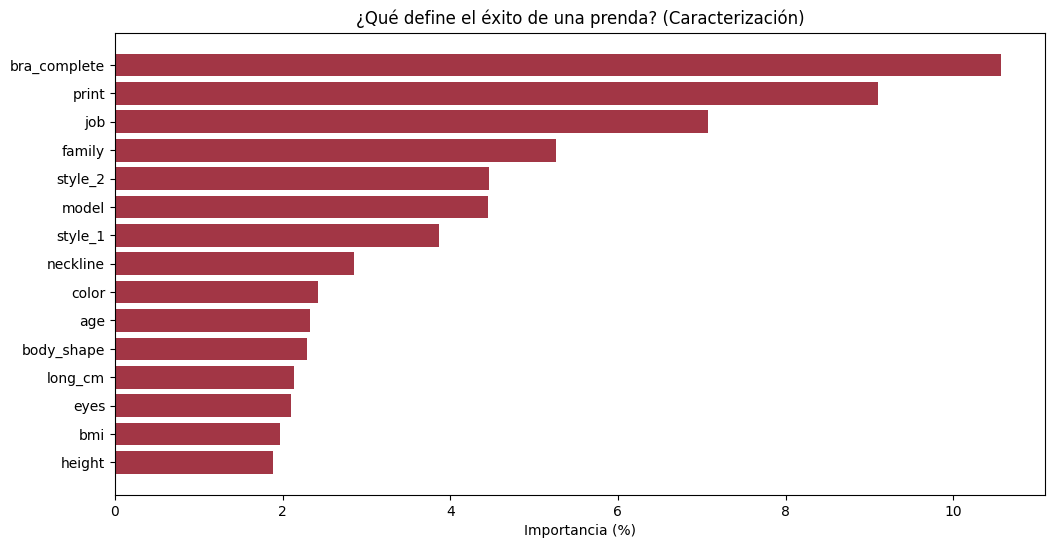

In [68]:
feature_importance = model.get_feature_importance(prettified=True)

print(feature_importance.head(10))

plt.figure(figsize=(12, 6))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature Id'], top_features['Importances'], color='#A23645')
plt.xlabel('Importancia (%)')
plt.title('¿Qué define el éxito de una prenda? (Caracterización)')
plt.gca().invert_yaxis() 
plt.show()

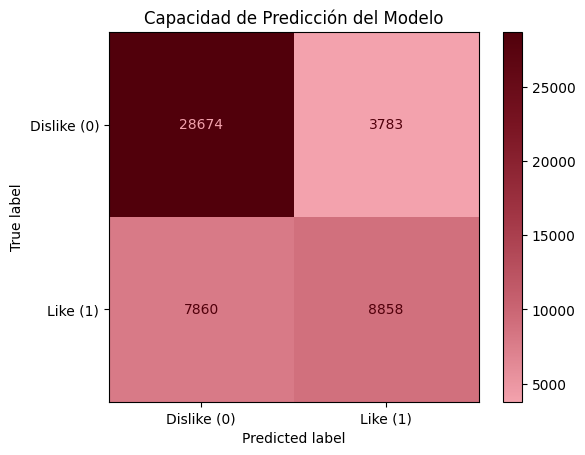

In [69]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

paleta = ['#F3A2AD', '#CA6573', '#A23645', '#791422', '#51000B']
cmap_final = mcolors.LinearSegmentedColormap.from_list("mi_paleta_4", paleta)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dislike (0)', 'Like (1)'])
disp.plot(cmap=cmap_final)
plt.title('Capacidad de Predicción del Modelo')
plt.show()